# Record the Data!

# 1. Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# import local directories
import sys
from pathlib import Path

REPO_DIR = Path.cwd().parent  # this notebook lives in record2/
for p in (REPO_DIR, REPO_DIR / "src"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))
sys.path = [p for p in sys.path if p not in ("", str(Path.cwd()))]  # record2/utils.py must not shadow the repo's utils/

In [3]:
import os, io, math, json, time, shutil, socket, threading, subprocess, dataclasses, collections, contextlib, webbrowser
from argparse import Namespace
from concurrent.futures import ThreadPoolExecutor
from dataclasses import dataclass, field
from datetime import datetime, timezone

import ctypes as ct
import numpy as np
import cv2
import sounddevice as sd
import soundfile as sf
from matplotlib.figure import Figure
from matplotlib.patches import Rectangle
from PIL import Image

from utils.ids_camera.pyueye_example_camera import Camera as _PyueyeCameraBase
from utils.ids_camera.pyueye_example_utils import uEyeException
from pyueye import ueye
from egrabber import *  # EGenTL, EGrabber, Buffer, BUFFER_INFO_* -- the Mikrotron/CoaXPress SDK

from utils.io_utils import save, append, load, load_metadata
from data.audio import main as generate_chirp_artifacts
from record2 import geometry, viz
from record2.image import crop
from record2.log import logger, setup_logging, Timing, TAIL, running
from record2.position_id import PositionIdCounter
from record2.post_process import post_process, preview_vibrations, warmup_pclk, PCLK_BATCH_SIZE, AUDIO_SAMPLE_RATE
from record2.segment import get_segmenter, segment, combined_smask, object_centers_of_mass
from record2.utils import close_previous_instance, stop_then_close
from record2.watcher import Watcher

In [4]:
setup_logging() # init logging

<Logger record2 (INFO)>

# 2. Overhead camera

In [5]:
@dataclass
class OverheadCameraConfig:
    device_id: int = 0
    exposure_bounds_ms: tuple = (0.1, 100.0)
    gain_bounds: tuple = (0, 100)
    frame_rate_bounds: tuple = (1.0, 60.0)
    exposure_ms: float = 12.0
    gain: int = 1
    frame_rate: float = 30.0
    pixel_clock: int = 86

In [6]:
class PyueyeCamera:
    # Streams from construction until close(); capture() returns the next fresh frame (RGB).
    _current = None  # the one open instance -- see close_previous_instance

    def __init__(self, config: OverheadCameraConfig):
        close_previous_instance(PyueyeCamera)
        self.config = config
        self.lock = threading.Lock()  # the GUI's live feed and record_position share this camera
        self._cam = _PyueyeCameraBase(device_id=config.device_id)
        self._cam.init()
        self._cam.set_colormode(ueye.IS_CM_SENSOR_RAW8)
        self._cam.alloc(buffer_count=40)
        self._cam.set_pixel_clock(config.pixel_clock)
        self.set_exposure(config.exposure_ms)
        self.set_gain(config.gain)
        self.frame_rate = self._cam.set_frame_rate(config.frame_rate)  # what the camera actually runs at
        aoi = self._cam.get_aoi()
        self.width, self.height = aoi.width, aoi.height
        self._cam.disable_external_trigger()
        self._cam.capture_video()
        PyueyeCamera._current = self

    def close(self):
        # stop streaming, then release the handle -- else the next PyueyeCamera fails with IS_DEVICE_IN_USE
        self._cam.stop_video()
        self._cam.exit()
        if PyueyeCamera._current is self:
            PyueyeCamera._current = None

    def set_exposure(self, exposure_ms):
        self._cam.set_exposure(exposure_ms)
        self.config = dataclasses.replace(self.config, exposure_ms=exposure_ms)

    def set_gain(self, gain):
        self._cam.set_gain(int(gain))
        self.config = dataclasses.replace(self.config, gain=int(gain))

    def get_exposure(self): return self._cam.get_exposure()
    def get_gain(self): return self._cam.get_gain()
    def get_pixel_clock(self): return self._cam.get_pixel_clock()

    def capture(self) -> np.ndarray:
        # The driver's queue is FIFO and read_frame pops the OLDEST frame -- drop the backlog first,
        # so this is the next exposure, not one from ~1 s ago.
        with self.lock:
            pending = ueye.UINT()
            ueye.is_ImageQueue(self._cam.h_cam, ueye.IS_IMAGE_QUEUE_CMD_GET_PENDING, pending, ueye.sizeof(pending))
            if pending.value:
                ueye.is_ImageQueue(self._cam.h_cam, ueye.IS_IMAGE_QUEUE_CMD_DISCARD_N_ITEMS, pending, ueye.sizeof(pending))
            out = self._cam.read_frame()
        if out is None:
            raise uEyeException(self._cam.last_error)
        return cv2.rotate(cv2.cvtColor(out[0].astype("uint8"), cv2.COLOR_BAYER_BG2RGB), cv2.ROTATE_180)

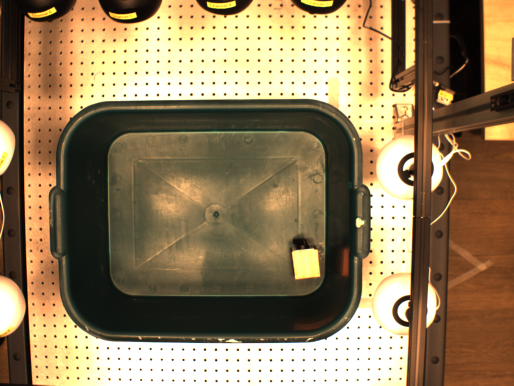

In [7]:
overhead_cam = PyueyeCamera(OverheadCameraConfig())
Image.fromarray(overhead_cam.capture()).reduce(4)

# 3. Laser camera

In [8]:
@dataclass
class LaserCameraConfig:
    sensor_width: int = 1920
    sensor_height: int = 1080
    exposure_bounds_us: tuple = (1.0, 2000.0)
    gain_bounds: tuple = (0.0, 24.0)
    fps_bounds: tuple = (1250.0, 5000.0)  # the GUI slider's; the camera caps fps at its max for the ROI
    roi: "ROIConfig | None" = None  # None = wide-open (full sensor); section 5 sets the ROI grid
    exposure_us: float = 130.0
    gain: float = 1.0
    fps: float = 2500.0  # capped at the camera's max for the ROI; > 2000 for post-processing's 1000 Hz band (Nyquist)
    # Frames per buffer B. The camera hands over only full buffers, so the live feed refreshes fps / B
    # times a second (20 at 125), and a capture can start up to one buffer early -- B must divide
    # speaker_padding * fps so the padding absorbs it and a capture is a whole number of buffers.
    buffer_part_count: int = 125
    laser_power: float = 500.0  # set by hand on the laser; only recorded in metadata

In [9]:
class MikrotronCamera:
    # The laser camera. Streams from construction until close(). Every grabber call holds self.lock:
    # egrabber refuses a call from one thread while another is inside it ("EGrabber is busy").
    _current = None  # the one open instance -- see close_previous_instance

    def __init__(self, config: LaserCameraConfig):
        close_previous_instance(MikrotronCamera)
        self.config = config
        self.lock = threading.RLock()
        self.latest_frame, self._frame_seq, self._preview_seq = None, 0, 0  # newest frame read, by anyone
        self._gentl = EGenTL()
        try:
            self.grabber = EGrabber(self._gentl)
        except InvalidAddressException:  # "DevGetPort: ... out of range": no camera on the CoaXPress link
            camera_found = False
        else:
            camera_found = True
        if not camera_found:  # raised outside the except, so no traceback keeps the EGenTL alive
            self._gentl = None
            raise RuntimeError("Laser camera not found. Is the laser camera turned on? Turn it on, wait for it to boot, then re-run this cell.")
        # The camera keeps its settings (acquiring, offsets, multi-ROI) across kernel restarts: always
        # start from one known state -- idle, full sensor, no multi-ROI, 1 frame per buffer.
        try:
            self.grabber.remote.execute("AcquisitionStop")  # a camera left acquiring locks MultiROILUTModeEn
        except Exception:
            pass
        self.grabber.stream.set("BufferPartCount", 1)  # the real value only once the frame is small (below)
        self.reset_global_roi()
        self.set_exposure(config.exposure_us)
        self.set_gain(config.gain)
        if config.roi is not None:
            self._apply_roi_grid(config.roi)
            self._set_buffer_part_count(config.buffer_part_count)
        # explicit: the camera keeps its last rate (25 fps once). Capped: the max depends on the ROI.
        self.set_frame_rate(min(config.fps, self.get_max_frame_rate()))
        self.grabber.flush_buffers()
        self.grabber.start()
        MikrotronCamera._current = self

    def close(self):
        # stop() before close(): stop() sends AcquisitionStop to the camera; else the next handle finds
        # features locked. Then drop grabber AND EGenTL (one per process) so re-opening works.
        with self.lock:
            stop_then_close(self.grabber)
            self.grabber = None
        self._gentl = None
        if MikrotronCamera._current is self:
            MikrotronCamera._current = None

    def _get(self, name):
        with self.lock: return self.grabber.remote.get(name)

    def _set(self, name, value):
        with self.lock: self.grabber.remote.set(name, value)

    def set_exposure(self, exposure_us):
        self._set("ExposureTime", exposure_us)
        self.config = dataclasses.replace(self.config, exposure_us=exposure_us)

    def set_gain(self, gain):
        self._set("Gain", gain)
        self.config = dataclasses.replace(self.config, gain=gain)

    def get_exposure(self): return self._get("ExposureTime")
    def get_gain(self): return self._get("Gain")
    def get_frame_rate(self): return self._get("AcquisitionFrameRate")
    def set_frame_rate(self, frame_rate): self._set("AcquisitionFrameRate", frame_rate)
    def get_max_frame_rate(self): return self._get("AcquisitionFrameRateMax")
    def get_global_roi(self): return tuple(self._get(name) for name in ("OffsetX", "OffsetY", "Width", "Height"))

    def _set_buffer_part_count(self, buffer_part_count):
        self.grabber.stop()
        self.grabber.stream.set("BufferPartCount", buffer_part_count)
        self.grabber.realloc_buffers(20)

    def _reset_buffer(self):
        # never start() here: the camera locks remote features while acquiring; __init__ starts once, at the end
        self.width, self.height = self.grabber.stream.get("Width"), self.grabber.stream.get("Height")
        self.grabber.stop()
        self.grabber.realloc_buffers(20)

    def reset_global_roi(self):
        self.grabber.stop()
        self.grabber.remote.set("MultiROILUTModeEn", False)
        self.grabber.remote.set("OffsetX", 0)
        self.grabber.remote.set("OffsetY", 0)
        self.grabber.remote.set("Width", self.config.sensor_width)
        self.grabber.remote.set("Height", self.config.sensor_height)
        self._reset_buffer()

    def set_global_roi_noy(self, x, y, w, h):
        if w < 128 or w % 16 != 0 or w > self.config.sensor_width:
            raise ValueError("Width must be > 128px and a multiple of 16")
        if x % 16 != 0:
            raise ValueError("OffsetX must be a multiple of 16")
        # the camera enforces Width + OffsetX <= 1920 at every step and OffsetX survives restarts:
        # zero it first, then size, then the real offset
        self.grabber.remote.set("OffsetX", 0)
        self.grabber.remote.set("Width", w)
        self.grabber.remote.set("Height", h)
        self.grabber.remote.set("OffsetX", x)
        self._reset_buffer()

    def set_rows(self, row_idxs):
        self.grabber.remote.set("MultiROILUTModeEn", False)
        if len(row_idxs) * 2 % 4 != 0:
            raise ValueError("row count must produce a height that's a multiple of 4")
        for i, idx in enumerate(row_idxs):
            self.grabber.remote.set("MultiROILUTIndex", i)
            self.grabber.remote.set("MultiROILUTValue", int(idx))
        self.grabber.remote.set("Height", len(row_idxs) * 2)
        self.grabber.remote.set("MultiROILUTModeEn", True)
        self._reset_buffer()

    def _apply_roi_grid(self, roi):
        offset_x, width = geometry.readout_columns(*roi.crop, self.config.sensor_width)  # the crop, on the camera's 16 px grid
        self.set_global_roi_noy(offset_x, 0, width, roi.n_rows * roi.roi_height)
        row_idxs = []  # one row register per 2 sensor rows
        for y0 in roi.row_positions:
            row_idxs.extend((np.arange(y0, y0 + roi.roi_height, 2) // 2).tolist())
        self.set_rows(row_idxs)

    def flush(self):
        with self.lock: self.grabber.flush_buffers()

    def _frame_shape(self): return self.get_global_roi()[-1], self.grabber.stream.get("Width")

    def _frames(self, buffer, first, n, shape):
        # n frames from part `first` of a popped buffer, in one copy (a buffer's frames are contiguous)
        base = buffer.get_info(BUFFER_INFO_BASE, INFO_DATATYPE_PTR)
        part_size = buffer.get_info(BUFFER_INFO_CUSTOM_PART_SIZE, INFO_DATATYPE_SIZET)
        data = ct.cast(base + first * part_size, ct.POINTER(ct.c_ubyte * (n * part_size))).contents
        return np.frombuffer(data, dtype=np.uint8).reshape(n, *shape)

    def capture_latest_frame(self) -> np.ndarray:
        # The newest frame: the board queues up to 20 full buffers and pops the oldest, so drop the
        # backlog, wait for the buffer being filled now, and take its last frame.
        with self.lock:
            self.grabber.flush_buffers()
            shape = self._frame_shape()
            with Buffer(self.grabber, timeout=5000) as buffer:
                delivered = buffer.get_info(BUFFER_INFO_CUSTOM_NUM_DELIVERED_PARTS, INFO_DATATYPE_SIZET)
                if delivered == 0:
                    raise RuntimeError("camera delivered an empty buffer")
                frame = self._frames(buffer, delivered - 1, 1, shape)[0].copy()
        self._publish(frame)
        return frame

    def _publish(self, frame):
        self.latest_frame, self._frame_seq = frame, self._frame_seq + 1

    def preview_frame(self):
        # The live feed, never waiting on a recording: read the newest frame if the camera is free,
        # else show the newest frame the recording read. None = nothing new since the last call.
        if self.lock.acquire(blocking=False):
            try:
                self.capture_latest_frame()
            finally:
                self.lock.release()
        if self._frame_seq == self._preview_seq:
            return None
        self._preview_seq = self._frame_seq
        return self.latest_frame

    def capture_vibrations(self, n_frames: int) -> np.ndarray:
        with self.lock:
            video, done = np.empty((n_frames, *self._frame_shape()), dtype=np.uint8), 0
            while done < n_frames:
                with Buffer(self.grabber, timeout=5000) as buffer:
                    delivered = buffer.get_info(BUFFER_INFO_CUSTOM_NUM_DELIVERED_PARTS, INFO_DATATYPE_SIZET)
                    if delivered == 0:
                        raise RuntimeError("camera delivered an empty buffer")
                    n = min(delivered, n_frames - done)
                    video[done:done + n] = self._frames(buffer, 0, n, video.shape[1:])
                    done += n
                    self._publish(video[done - 1].copy())  # keeps the live feed moving during a recording
            return video

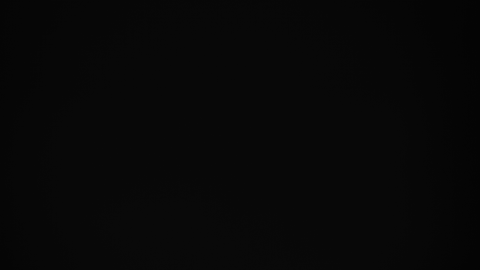

In [10]:
laser_cam = MikrotronCamera(LaserCameraConfig())
Image.fromarray(laser_cam.capture_latest_frame()).reduce(4)

# 4. ROIs

In [11]:
SET_ROIS = False

In [12]:
@dataclass
class ROIConfig:
    # the lines you click (sensor px) and the ROI size -- the camera's grid is derived from them
    n_rows: int = 10
    n_cols: int = 10
    rows: list[int] | None = None  # y of each horizontal line; None = n_rows spread evenly over the sensor
    cols: list[int] | None = None  # x of each vertical line; None = n_cols spread evenly over the crop
    crop: tuple[int, int] = (0, 1920)  # sensor columns [left, right) the camera reads (on its 16 px grid)
    roi_width: int = 80   # px -- small: pclk cost scales with ROI pixels
    roi_height: int = 32  # px -- a multiple of 4 (the camera reads row pairs, and needs rows x 2 % 4 == 0)

    def __post_init__(self):
        if self.roi_height % 4:
            raise ValueError(f"roi_height={self.roi_height} must be a multiple of 4 (camera row rule)")
        spread = lambda start, end, n: [int(start + (end - start) * (i + 0.5) / n) for i in range(n)]
        self.rows = self.rows or spread(0, 1080, self.n_rows)
        self.cols = self.cols or spread(*self.crop, self.n_cols)
        self.n_rows, self.n_cols, self.crop = len(self.rows), len(self.cols), tuple(self.crop)
        # rois: (x, y, w, h) in the camera's OUTPUT frame; row_positions: sensor row of each band; offset_x: first sensor column
        self.rois, self.row_positions, self.offset_x = geometry.compute_roi_grid(
            self.rows, self.cols, self.roi_width, self.roi_height, self.crop)


ROIS_FILE = REPO_DIR / "record2" / "rois.json"  # the last-used ROIs
def load_rois(): return ROIConfig(**json.loads(ROIS_FILE.read_text())) if ROIS_FILE.exists() else ROIConfig()
def save_rois(roi): ROIS_FILE.write_text(json.dumps(dict(rows=roi.rows, cols=roi.cols, crop=roi.crop, roi_width=roi.roi_width, roi_height=roi.roi_height)))


In [13]:
roi_config = ROIConfig() if SET_ROIS else load_rois()

In [14]:
def open_calibration_camera(config: LaserCameraConfig) -> MikrotronCamera:
    # wide-open: the whole sensor to click on (replaces the current laser camera)
    return MikrotronCamera(dataclasses.replace(config, roi=None))


def click_lines(camera: MikrotronCamera, n: int, horizontal: bool, roi: ROIConfig, crop=None) -> list[int]:
    # n clicks on the live feed in a full-screen OpenCV window -> the sensor y of each horizontal line,
    # or the sensor x of each vertical one. crop=(left, right): show only those columns. Esc cancels.
    left, right = crop or (0, camera.config.sensor_width)
    what = "HORIZONTAL" if horizontal else "VERTICAL"
    window, clicks = f"Click {n} {what} lines (Esc cancels)", []
    cv2.namedWindow(window, cv2.WINDOW_NORMAL)
    cv2.setWindowProperty(window, cv2.WND_PROP_FULLSCREEN, cv2.WINDOW_FULLSCREEN)
    cv2.setWindowProperty(window, cv2.WND_PROP_TOPMOST, 1)
    cv2.setMouseCallback(window, lambda event, x, y, *_: clicks.append(y if horizontal else x + left) if event == cv2.EVENT_LBUTTONDOWN else None)
    blue = (255, 144, 30)  # BGR
    try:
        while len(clicks) < n:
            frame = cv2.cvtColor(camera.capture_latest_frame()[:, left:right], cv2.COLOR_GRAY2BGR)
            h, w = frame.shape[:2]
            for y in (clicks if horizontal else roi.rows):
                cv2.line(frame, (0, int(y)), (w, int(y)), blue, 2)
            for x in ([] if horizontal else clicks):
                cv2.line(frame, (int(x) - left, 0), (int(x) - left, h), blue, 2)
            cv2.putText(frame, f"{what} lines: {len(clicks)}/{n}", (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.5, blue, 3)
            cv2.imshow(window, frame)
            if cv2.waitKey(30) == 27:  # Esc
                raise KeyboardInterrupt("cancelled -- roi_config unchanged")
    finally:
        cv2.destroyWindow(window)
    return clicks


def plot_lines(wide_open_frame, rows=(), cols=(), crop=None):
    left, right = crop or (0, wide_open_frame.shape[1])
    fig = Figure(figsize=(8, 5), layout="tight")
    ax = fig.subplots()
    ax.imshow(wide_open_frame[:, left:right], cmap="gray", vmin=0, vmax=255, extent=(left, right, wide_open_frame.shape[0], 0))
    for y in rows:
        ax.axhline(y, color="#1e90ff", lw=1)
    for x in cols:
        ax.axvline(x, color="#1e90ff", lw=1)
    ax.set_title(f"{len(rows)} horizontal, {len(cols)} vertical lines" + (f", columns {left}-{right}" if crop else ""))
    ax.axis("off")
    return Image.fromarray(viz.figure_to_array(fig))


def plot_rois(wide_open_frame, roi: ROIConfig, zoomed=False):
    # zoomed out: the full sensor with the ROI boxes; zoomed in: only the ROI cells, tiled
    if zoomed:
        cropped = geometry.crop_rois(wide_open_frame, roi.rois, roi.row_positions, roi.offset_x, roi.roi_height)
        image, boxes = geometry.roi_mosaic(cropped, roi.rois, roi.n_cols)
    else:
        image, boxes = wide_open_frame, geometry.sensor_rois(roi.rois, roi.row_positions, roi.offset_x, roi.roi_height)
    fig = Figure(figsize=(10, 6), layout="tight")
    ax = fig.subplots()
    ax.imshow(image, cmap="gray", vmin=0, vmax=255)
    for x, y, w, h in boxes:
        ax.add_patch(Rectangle((x - 0.5, y - 0.5), w, h, fill=False, edgecolor="#1e90ff", lw=1))
    ax.set_title(f"{len(roi.rois)} ROIs, {roi.roi_width} x {roi.roi_height} px" + (" (zoomed in)" if zoomed else ""))
    ax.axis("off")
    return Image.fromarray(viz.figure_to_array(fig))

## 1. Horiztonal ROIs

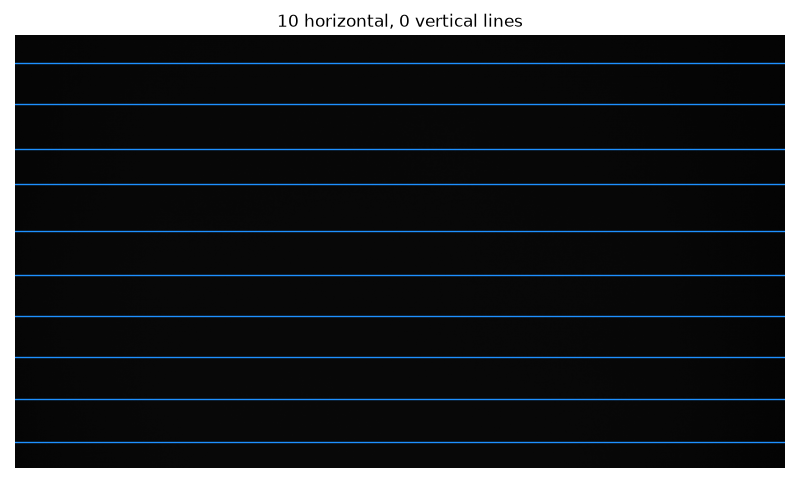

In [15]:
laser_cam = open_calibration_camera(laser_cam.config)
wide_open_frame = laser_cam.capture_latest_frame()
if SET_ROIS:
    rows = click_lines(laser_cam, roi_config.n_rows, horizontal=True, roi=roi_config)
    roi_config = dataclasses.replace(roi_config, rows=rows)
plot_lines(wide_open_frame, rows=roi_config.rows)

## 2. Crop ROIs

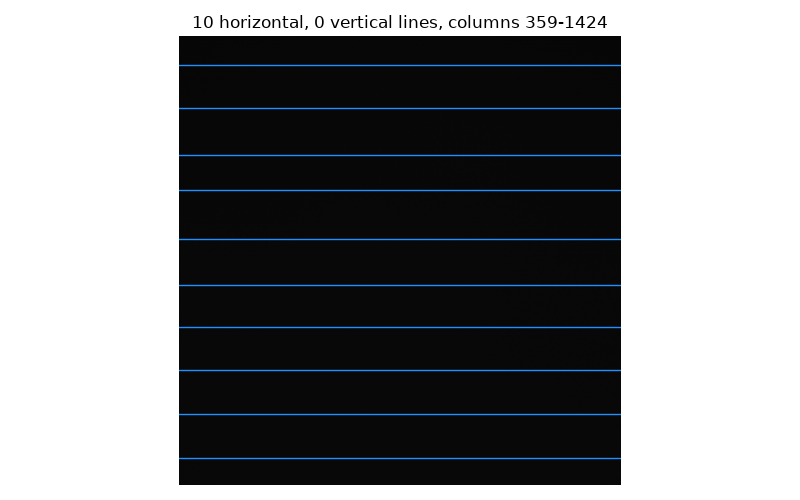

In [16]:
if SET_ROIS:
    edges = click_lines(laser_cam, 2, horizontal=False, roi=roi_config)  # LEFT + RIGHT edge, any order
    roi_config = dataclasses.replace(roi_config, crop=(min(edges), max(edges)), cols=None)
plot_lines(wide_open_frame, rows=roi_config.rows, crop=roi_config.crop)

## 3. Vertical ROIs

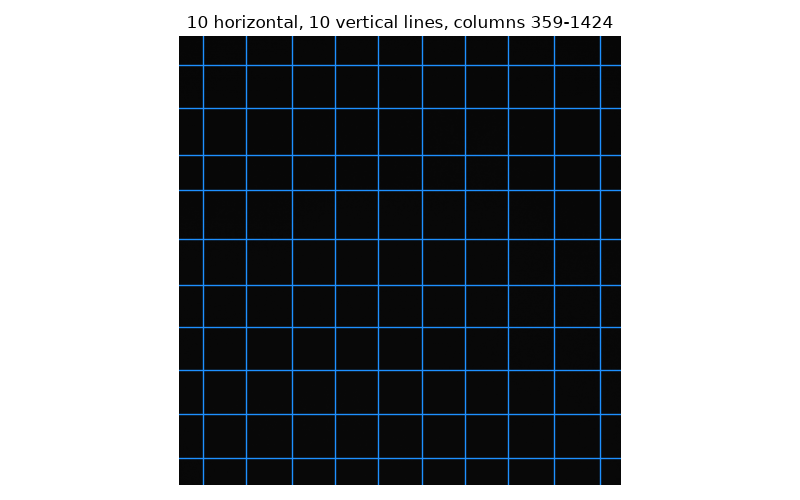

In [17]:
if SET_ROIS:
    cols = click_lines(laser_cam, roi_config.n_cols, horizontal=False, roi=roi_config, crop=roi_config.crop)
    roi_config = dataclasses.replace(roi_config, cols=cols)
plot_lines(wide_open_frame, rows=roi_config.rows, cols=roi_config.cols, crop=roi_config.crop)

## 4. ROI width + height

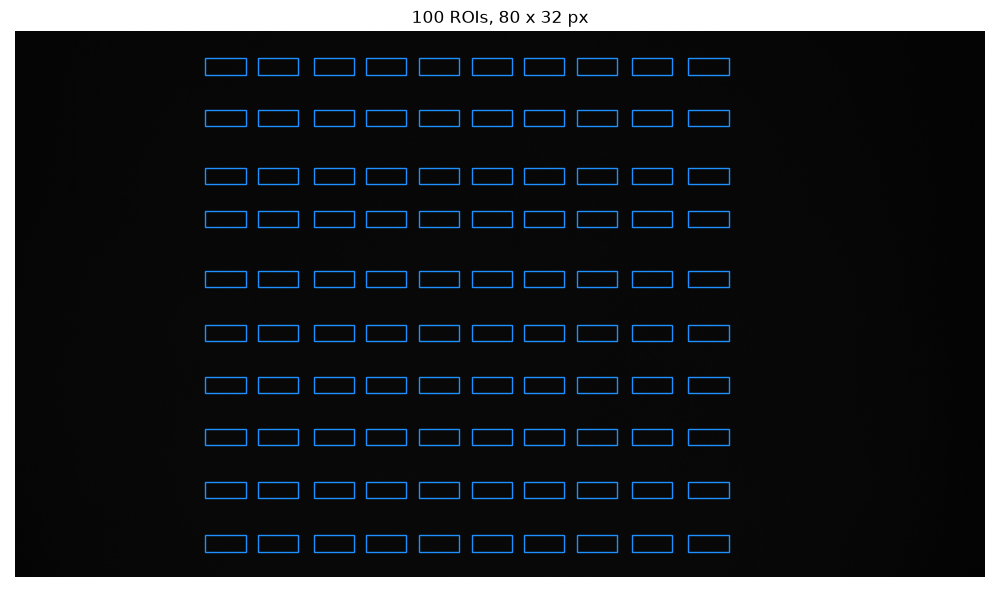

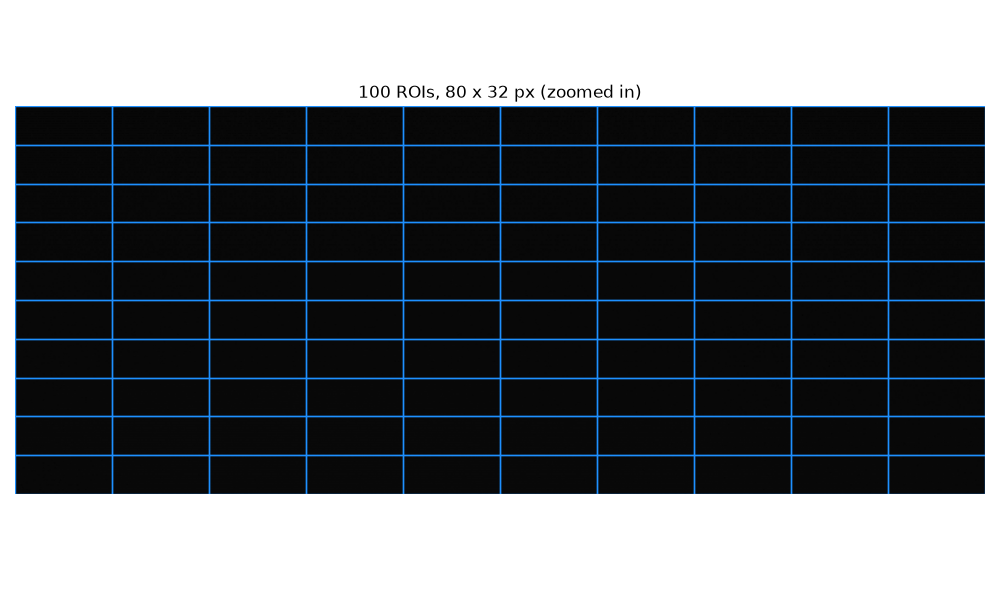

In [18]:
if SET_ROIS:
    roi_config = dataclasses.replace(roi_config, roi_width=76, roi_height=32)
    save_rois(roi_config)
laser_cam = MikrotronCamera(dataclasses.replace(laser_cam.config, roi=roi_config))  # cropped to the grid -- clicked, or the default even one (closes the wide-open one)
display(plot_rois(wide_open_frame, roi_config))
plot_rois(wide_open_frame, roi_config, zoomed=True)

In [19]:
if SET_ROIS:
    save_rois(roi_config)

# 5. Speakers

In [20]:
@dataclass
class AudioConfig:
    # speaker -> sound-card name substring, and speaker -> (channel, mono)
    speaker_device_names: dict = field(default_factory=lambda: {
        1: "Main Out 1-2", 2: "Main Out 1-2", 3: "Line Out 3-4", 4: "Line Out 3-4",
        5: "Line Out 5-6", 6: "Line Out 5-6", 7: "Line Out 7-8", 8: "Line Out 7-8"})
    speaker_channels: dict = field(default_factory=lambda: {
        1: (0, False), 2: (1, False), 3: (1, False), 4: (0, False),
        5: (0, False), 6: (1, False), 7: (0, False), 8: (1, False)})
    sample_rate: int = 0  # 0 = the first device's default rate
    settle_seconds: float = 0.25  # WASAPI shared-mode output latency guard (recorded in metadata)
    speaker_delay: float = 0.1  # silence BEFORE each speaker, so the box settles
    speaker_padding: float = 0.1  # extra seconds captured AFTER the chirp ends

In [21]:
audio_config = AudioConfig()
audio_config

AudioConfig(speaker_device_names={1: 'Main Out 1-2', 2: 'Main Out 1-2', 3: 'Line Out 3-4', 4: 'Line Out 3-4', 5: 'Line Out 5-6', 6: 'Line Out 5-6', 7: 'Line Out 7-8', 8: 'Line Out 7-8'}, speaker_channels={1: (0, False), 2: (1, False), 3: (1, False), 4: (0, False), 5: (0, False), 6: (1, False), 7: (0, False), 8: (1, False)}, sample_rate=0, settle_seconds=0.25, speaker_delay=0.1, speaker_padding=0.1)

In [22]:
def _find_output_device(name_substring: str, hostapi_name: str = "Windows WASAPI") -> int:
    hostapi = next(i for i, h in enumerate(sd.query_hostapis()) if h["name"] == hostapi_name)
    for idx, dev in enumerate(sd.query_devices()):
        if dev["hostapi"] == hostapi and name_substring in dev["name"] and dev["max_output_channels"] > 0:
            return idx
    raise ValueError(f"No output device matching {name_substring!r}")


def _as_audio(a) -> np.ndarray:
    if isinstance(a, (str, Path)):
        return sf.read(str(a), dtype="float32", always_2d=True)[0].mean(1)
    a = np.asarray(a, np.float32)
    return a.mean(1) if a.ndim > 1 else a

class AudioEngine:
    # One open output stream per sound card. play() returns at once; wait() blocks until it's done.
    def __init__(self, config: AudioConfig):
        self.config = config
        self._device_index = {name: _find_output_device(name) for name in sorted(set(config.speaker_device_names.values()))}
        self._devices = sorted(set(self._device_index.values()))
        self.sample_rate = config.sample_rate or int(sd.query_devices(self._devices[0])["default_samplerate"])
        self._locks = {d: threading.Lock() for d in self._devices}
        self._streams, self._playing, self._errors = {}, [], []
        self._open_streams()

    def _open_streams(self):
        for d in self._devices:
            self._streams[d] = sd.OutputStream(samplerate=self.sample_rate, device=d, channels=2, blocksize=1024)
            self._streams[d].start()
        logger.info(f"audio: opened {len(self._streams)} output streams {self._devices}")

    def close(self):
        for s in self._streams.values():
            try:
                s.abort(); s.close()
            except Exception:
                pass
        self._streams.clear()
        logger.info("audio: closed the output streams")

    def reset(self):  # after a failed capture: reopen every stream
        self.close()
        self._open_streams()

    def _feed(self, device, buf, errors):
        try:
            with self._locks[device]:
                t0 = time.perf_counter()
                self._streams[device].write(buf)
                time.sleep(max(0, len(buf) / self.sample_rate - (time.perf_counter() - t0)))
        except Exception as e:
            errors.append(e)  # for wait(): a sound that didn't play must fail the recording, not pass silently
            raise

    def play(self, audio, speakers):
        if not self._streams:
            raise RuntimeError("the audio engine is closed -- call reset()")
        audio, per_device = _as_audio(audio), {}
        for spk in speakers:
            device = self._device_index[self.config.speaker_device_names[spk]]
            channel, mono = self.config.speaker_channels[spk]
            buf = per_device.setdefault(device, np.zeros((len(audio), 2), np.float32))
            if mono:
                buf[:, 0] = buf[:, 1] = audio
            else:
                buf[:, channel] = audio
        self._speakers, self._errors = list(speakers), []
        self._playing = [threading.Thread(target=self._feed, args=(*item, self._errors), daemon=True, name="audio") for item in per_device.items()]
        for t in self._playing:
            t.start()

    def wait(self):
        for t in self._playing:
            t.join()
        if self._errors:
            raise RuntimeError(f"playing on speakers {self._speakers} failed: {self._errors[0]!r}") from self._errors[0]

In [23]:
audio_engine = AudioEngine(audio_config)
audio_engine

2026-10-04 16:53:46,411 MainThread            INFO  audio: opened 4 output streams [30, 32, 34, 35]


In [24]:
done_whistle_samples = _as_audio(REPO_DIR / "data" / "whatsapp-whistle.mp3")
audio_engine.play(done_whistle_samples, speakers=[1, 3, 5, 7])

# 6. Hardware

In [25]:
@dataclass
class Hardware:
    overhead_cam: PyueyeCamera
    laser_cam: MikrotronCamera
    audio_engine: AudioEngine


hw = Hardware(overhead_cam, laser_cam, audio_engine)  # re-run after re-running the ROI cells: a new laser_cam closes the old one
lc, ac = hw.laser_cam.config, hw.audio_engine.config
assert round(ac.speaker_padding * lc.fps) % lc.buffer_part_count == 0, "buffer_part_count must divide speaker_padding * fps"

# 7. Chrip

In [26]:
@dataclass
class ChirpConfig:
    t_sec: float = 1.0
    t_start: float = 0.1  # silence before
    t_end: float = 0.1  # silence after
    f_start: float = 100.0
    f_end: float = 1000.0

In [27]:
chirp_config = ChirpConfig()
chirp_config

ChirpConfig(t_sec=1.0, t_start=0.1, t_end=0.1, f_start=100.0, f_end=1000.0)

In [28]:
chirp_samples, _ = generate_chirp_artifacts(Namespace(T_sec=chirp_config.t_sec, T_start=chirp_config.t_start, T_end=chirp_config.t_end,
                                                      fs=hw.audio_engine.sample_rate, f_start=chirp_config.f_start,
                                                      f_end=chirp_config.f_end, out_dir=None))
chirp_samples = chirp_samples.astype(np.float32) / np.iinfo(np.int16).max
hw.audio_engine.play(chirp_samples, speakers=[3])

Already computed audio in C:\Users\eitanturok\good-vibrations\data\audio\chirp_100_1000_1.0sec


# 8. Experiment

In [29]:
@dataclass
class PositionConfig:
    speakers: list
    box: str
    crop: tuple  # (left, right, top, bottom) of the overhead frame -- usually exp.crop_box[box]
    objects: dict  # object -> how many
    prompts: dict  # object -> segmentation prompt -- usually exp.prompts[object]
    layout: str
    description: str = ""

    def __post_init__(self):
        if missing := [o for o in self.objects if not self.prompts.get(o)]:
            raise ValueError(f"no segmentation prompt for {missing}")

In [30]:
default_position = PositionConfig(speakers=[1, 3, 5, 7], box="gastronorm", crop=json.loads((REPO_DIR / "record2" / "crop_box.json").read_text())["gastronorm"],
                                  objects={}, prompts={}, layout="empty", description="An empty gastronorm box from a bird's eye view.")
default_position

PositionConfig(speakers=[1, 3, 5, 7], box='gastronorm', crop=[0.032, 0.696, 0.166, 0.887], objects={}, prompts={}, layout='empty', description="An empty gastronorm box from a bird's eye view.")

In [31]:
@dataclass
class PreviewConfig:
    speaker: int = 1  # whose capture is previewed (shifts, FFT, audio) right after recording
    laser: int = 55  # which ROI -- also the laser recovered_audio.wav uses
    channel: int = 0  # 0 = x, 1 = y
    use_pc: bool = True

In [32]:
default_preview = PreviewConfig()

In [33]:
class Experiment:
    def __init__(self, experiment_dir, chirp_config, chirp_samples, done_whistle_samples, hand_delay=0.15, segment_scale=1.0, min_free_gb=50.0):
        self.experiment_dir = Path(experiment_dir)
        self.samples_dir = self.experiment_dir / "samples"
        self.samples_dir.mkdir(parents=True, exist_ok=True)
        setup_logging(self.experiment_dir / "record.log")  # record.log + times.jsonl, next to the samples
        self.chirp_config, self.chirp_samples, self.done_whistle_samples = chirp_config, chirp_samples, done_whistle_samples
        self.chirp_seconds = chirp_config.t_start + chirp_config.t_sec + chirp_config.t_end
        self.hand_delay = hand_delay  # seconds before the overhead photo, so your hand is out of it
        self.segment_scale = segment_scale  # < 1: segment a smaller image (faster); masks come back full size
        self.min_free_gb = min_free_gb  # don't start a position unless its raws fit with this much to spare
        self.git_commit = subprocess.run(["git", "rev-parse", "HEAD"], capture_output=True, text=True).stdout.strip() or None
        self.hostname = socket.gethostname()
        self.position_ids = PositionIdCounter()  # one counter for every experiment, ever
        for name in ("crop_box", "segmentation_prompts", "speaker_position"):  # defaults in record2/, edit the experiment's copy
            if not (self.experiment_dir / f"{name}.json").exists():
                shutil.copy(REPO_DIR / "record2" / f"{name}.json", self.experiment_dir)
        self.crop_box = json.loads((self.experiment_dir / "crop_box.json").read_text())  # box -> (left, right, top, bottom)
        self.prompts = json.loads((self.experiment_dir / "segmentation_prompts.json").read_text())  # object -> prompt
        self.speaker_position = {int(k): v for k, v in json.loads((self.experiment_dir / "speaker_position.json").read_text()).items()}  # speaker -> (x, y)
        self.load_coverage()

    def __repr__(self):
        c = self.chirp_config
        layouts = ", ".join(f"{k} {n}" for k, n in sorted(self.positions_per_layout.items()))
        return "\n".join([
            f"Experiment {self.experiment_dir}",
            f"  saved positions: {sum(self.positions_per_layout.values())}" + (f" ({layouts})" if layouts else ""),
            f"  next position id: {self.position_ids.peek()}",
            f"  disk: {shutil.disk_usage(self.experiment_dir).free / 1e9:.0f} GB free (keeps {self.min_free_gb:g})",
            f"  chirp: {c.f_start:g}-{c.f_end:g} Hz, {self.chirp_seconds:g} s; hand delay {self.hand_delay:g} s; segment scale {self.segment_scale:g}",
            f"  git {(self.git_commit or '?')[:8]} on {self.hostname}"])

    def load_coverage(self):
        # coverage + saved positions per layout, from disk: one smask per position (its speakers share it).
        # Read once; call again after changing samples/ by hand (deleting dirs, or the whole folder)
        self.samples_dir.mkdir(parents=True, exist_ok=True)
        self.coverage, self.positions_per_layout, seen = {}, collections.Counter(), set()
        for d in sorted(self.samples_dir.iterdir()):
            position_id = d.name.split("-")[0]
            if position_id in seen or not (d / "image/03_smask.npy").exists():
                continue
            seen.add(position_id)
            layout = load_metadata(d / "metadata.jsonl").get("layout")
            if layout is not None:
                masks = [load(f) for f in sorted((d / "image/smasks").glob("*.npy"))]  # each object, outlined on the plot
                self.coverage[layout] = viz.add_coverage(self.coverage.get(layout), load(d / "image/03_smask.npy"), masks)
                self.positions_per_layout[layout] += 1

In [34]:
experiment_dir = Path(r"D:/eturok/2026_10_04_green_plastic_four_objects")  # set per recording session

In [35]:
exp = Experiment(experiment_dir, chirp_config, chirp_samples, done_whistle_samples)
exp

Experiment D:\eturok\2026_10_04_green_plastic_four_objects
  saved positions: 71 (empty 57, red-cube 14)
  next position id: 1455
  disk: 3333 GB free (keeps 50)
  chirp: 100-1000 Hz, 1.2 s; hand delay 0.15 s; segment scale 1
  git dbf0373f on DESKTOP-V0I29R5

In [36]:
# init async segmentation model on modal
segmenter = get_segmenter()
segmenter

In [37]:
# init async post processing script that does pclk, clean signal, computes fft, etc
if "post_processor" in globals():
    post_processor.stop()
post_processor = Watcher(post_process, exp.samples_dir, "*/vibration/01_raw_vibrations.npy").start()
post_process

<function record2.post_process.post_process(raw_path)>

# 7. Record

In [38]:
SAVE_POOL = ThreadPoolExecutor(2, thread_name_prefix="save")  # at most 2 raws (1-3 GB each) in RAM at once
WORK_POOL = ThreadPoolExecutor(2, thread_name_prefix="work")  # segmentation, preview
RECORD_POOL = ThreadPoolExecutor(1, thread_name_prefix="record")  # record_position in the background (GUI, record_position_and_plot)
STOP, RECORDING = threading.Event(), threading.Lock()
LAST = {}  # the last position, for display only: position_id, position, seg and preview (Futures)

In [39]:
def job(label, stage, fn, *args):
    # a timed background job (-> log + timeline); its result or exception stays in its Future
    with Timing(label, stage):
        return fn(*args)


def to_json(o): return o.tolist() if hasattr(o, "tolist") else str(o)


def write_metadata(metadata: dict, path: Path):
    # one key per line -- load_metadata merges the lines back into one dict
    with open(path, "a", encoding="utf-8") as f:
        f.writelines(json.dumps({k: v}, default=to_json) + "\n" for k, v in metadata.items())


def capture_seconds(hw, exp): return exp.chirp_seconds + hw.audio_engine.config.speaker_padding


def capture_frames(hw, exp, fps):
    return math.ceil(round(capture_seconds(hw, exp) * fps, 6))  # round first: 0.3 * 100 is 30.000000000000004


def check_disk(hw, exp, position):
    need = len(position.speakers) * capture_frames(hw, exp, hw.laser_cam.get_frame_rate()) * hw.laser_cam.width * hw.laser_cam.height + exp.min_free_gb * 1e9
    if (free := shutil.disk_usage(exp.experiment_dir).free) < need:
        raise OSError(f"only {free / 1e9:.0f} GB free, this position needs {need / 1e9:.0f} GB (raws + min_free_gb) -- "
                      "wait for post-processing to catch up, or free space")


def sample_metadata(hw, exp, position, preview, position_id, speaker, raw_overhead, crop_overhead) -> dict:
    # flat: the sample, then its position, cameras, speakers, chirp and processing settings
    oc, lc, ac, chirp, roi = hw.overhead_cam, hw.laser_cam, hw.audio_engine.config, exp.chirp_config, hw.laser_cam.config.roi
    fps, exposure_us, gain, max_frame_rate, global_roi = lc.get_frame_rate(), lc.get_exposure(), lc.get_gain(), lc.get_max_frame_rate(), list(lc.get_global_roi())
    channel, mono = ac.speaker_channels[speaker]
    seconds = capture_seconds(hw, exp)
    return dict(
        position_id=int(position_id), speaker=speaker, timestamp=datetime.now(timezone.utc).isoformat(),
        speaker_device_name=ac.speaker_device_names[speaker], speaker_channel=channel, speaker_mono=mono,
        experiment_dir=str(exp.experiment_dir), git_commit=exp.git_commit, hostname=exp.hostname,
        box=position.box, **dict(zip(("crop_left", "crop_right", "crop_top", "crop_bottom"), position.crop)),
        objects=position.objects, prompts=position.prompts, n_objects=sum(position.objects.values()), layout=position.layout,
        description=position.description, is_empty_box=not position.objects, speakers=list(position.speakers), save=True, vibrate=True,
        overhead_device_id=oc.config.device_id, overhead_exposure_ms=oc.get_exposure(), overhead_gain=oc.get_gain(),
        overhead_frame_rate=oc.frame_rate, overhead_pixel_clock=oc.get_pixel_clock(), hand_delay=exp.hand_delay,
        raw_overhead_shape=list(raw_overhead.shape), crop_overhead_shape=list(crop_overhead.shape),
        fps=fps, exposure_us=exposure_us, gain=gain, max_frame_rate=max_frame_rate, global_roi=global_roi,
        width=lc.width, height=lc.height, sensor_width=lc.config.sensor_width, sensor_height=lc.config.sensor_height,
        buffer_part_count=lc.config.buffer_part_count, capture_margin_s=ac.speaker_padding,
        n_frames=capture_frames(hw, exp, fps), n_capture_seconds=seconds, laser_power=lc.config.laser_power,
        **(dict(vars(roi)) if roi is not None else {"rois": None}),
        audio_fs=hw.audio_engine.sample_rate, **{f"chirp_{k}": getattr(chirp, k) for k in ("t_sec", "t_start", "t_end", "f_start", "f_end")},
        min_freq=chirp.f_start, max_freq=chirp.f_end, settle_seconds=ac.settle_seconds, speaker_delay=ac.speaker_delay,
        pclk_batch_size=PCLK_BATCH_SIZE, use_PC=preview.use_pc, laser_idx=preview.laser, preview_speaker=preview.speaker,
        audio_sample_rate=AUDIO_SAMPLE_RATE, recovery_laser=preview.laser, recovery_axis="xy"[preview.channel],
        segment_scale=exp.segment_scale,
        # legacy: src/record.ipynb's nested dicts
        run_opt={"cam_params": {"camera_FPS": fps, "exposure": exposure_us, "gain": gain, "get_global_roi": global_roi,
                                "get_frame_rate": fps, "get_max_frame_rate": max_frame_rate, "get_exposure": exposure_us}},
        run_opt_multiROIs=None if roi is None else {
            "N_ROIs": roi.n_rows, "ROI_height": roi.roi_height, "total_image_height": roi.n_rows * roi.roi_height,
            "global_ROI": global_roi, "ROIs": roi.rois, "ROI_list": [(y, y + roi.roi_height) for y in roi.row_positions]},
    )


def save_vibration(sample_dir: Path, raw: np.ndarray):
    # written as .tmp, then renamed: the post-process Watcher only ever sees a complete raw file
    path = sample_dir / "vibration" / "01_raw_vibrations.npy"
    tmp = path.with_suffix(".npy.tmp")
    with Timing(sample_dir.name, "save vibration", sample_dir):
        path.parent.mkdir(exist_ok=True)
        try:
            with open(tmp, "wb") as f:
                np.save(f, raw)
            os.replace(tmp, path)
        finally:
            tmp.unlink(missing_ok=True)


def segment_position(segmenter, crop_overhead, position, coverage_entry, scale) -> dict:
    seg = segment(segmenter, crop_overhead, position.prompts, position.objects, scale)
    smask = combined_smask(seg, crop_overhead.shape[:2])
    return dict(seg=seg, smask=smask, crop=crop_overhead,
                coverage=viz.add_coverage(coverage_entry, smask, [m for r in seg for m in r["masks"]]))


def save_segmentation(exp, position, position_id, raw_overhead, crop_overhead, seg):
    # the position's overhead + masks, written once and copied into every recorded speaker's sample dir
    dirs = sorted(exp.samples_dir.glob(f"{position_id}-*"))
    if not dirs:
        return
    first = dirs[0]
    with Timing(position_id, "save segmentation"):
        save(raw_overhead, first / "image/01_raw_overhead.png")
        save(crop_overhead, first / "image/02_cropped_overhead.png")
        save(seg["smask"], first / "image/03_smask.npy")
        save(seg["smask"], first / "image/03_smask.png")
        for name, r in zip(position.objects, seg["seg"]):
            for j, m in enumerate(r["masks"]):
                save(m, first / f"image/smasks/{name}{j}.npy")
        coms = object_centers_of_mass(seg["seg"])
        all_coms = [c for r in coms for c in r]
        metadata = dict(coms=coms, avg_com=np.mean(all_coms, axis=0).tolist() if all_coms else [],
                        seg_boxes=[r.get("boxes") for r in seg["seg"]], seg_scores=[r.get("scores") for r in seg["seg"]])
        for d in dirs:
            if d != first:
                shutil.copytree(first / "image", d / "image")
            write_metadata(metadata, d / "metadata.jsonl")

In [40]:
def record_position(hw, exp, segmenter, position, preview, save=True, vibrate=True) -> str:
    # record one position: take overhead photo + segment it and play a chirp from each speaker + capture vibrations

    if not RECORDING.acquire(blocking=False):
        raise RuntimeError("already recording")
    try:
        STOP.clear()
        if vibrate and hw.laser_cam.config.roi is None:
            raise ValueError("the laser camera has no ROI grid (it's wide-open) -- run the ROI cells, or set ROIs in the GUI")
        position_id = f"{exp.position_ids.next():06d}"  # every run, saved or not: one id, one row on the timeline
        with Timing(position_id, "position", speakers=list(position.speakers) if vibrate else [], save=save):
            if save and vibrate:
                check_disk(hw, exp, position)
            LAST.clear()
            LAST.update(position_id=position_id, position=position, preview_config=preview)
            with Timing(position_id, "overhead"):
                time.sleep(exp.hand_delay)
                raw_overhead = hw.overhead_cam.capture()
            crop_overhead = crop(raw_overhead, *position.crop)
            LAST["seg"] = WORK_POOL.submit(job, position_id, "segment", segment_position, segmenter, crop_overhead,
                                           position, exp.coverage.get(position.layout), exp.segment_scale)

            if vibrate:
                n_frames = capture_frames(hw, exp, hw.laser_cam.get_frame_rate())
                for speaker in position.speakers:
                    if STOP.is_set():
                        break
                    name = f"{position_id}-{speaker}"
                    sample_dir = exp.samples_dir / name if save else None
                    with Timing(name, "speaker", sample_dir):
                        if save:
                            sample_dir.mkdir(parents=True)
                            write_metadata(sample_metadata(hw, exp, position, preview, position_id, speaker, raw_overhead, crop_overhead),
                                           sample_dir / "metadata.jsonl")
                        time.sleep(hw.audio_engine.config.speaker_delay)
                        try:
                            with Timing(name, "vibrate", sample_dir):
                                hw.laser_cam.flush()  # drop buffers queued before this speaker
                                hw.audio_engine.play(exp.chirp_samples, [speaker])
                                raw = hw.laser_cam.capture_vibrations(n_frames)
                                hw.audio_engine.wait()
                        except Exception:
                            hw.audio_engine.reset()
                            raise
                        if save:
                            SAVE_POOL.submit(save_vibration, sample_dir, raw)
                        if speaker == preview.speaker:
                            roi = hw.laser_cam.config.roi.rois[preview.laser]
                            LAST["preview"] = WORK_POOL.submit(job, name, "preview", preview_vibrations, raw, roi, hw.laser_cam.get_frame_rate(),
                                                               preview.laser, preview.channel, exp.chirp_config.f_start,
                                                               exp.chirp_config.f_end, PCLK_BATCH_SIZE, preview.use_pc)

            with Timing(position_id, "segment wait"):
                seg = LAST["seg"].result()  # started right after the photo: done by now
            if save:
                exp.coverage[position.layout] = seg["coverage"]
                exp.positions_per_layout[position.layout] += 1
                SAVE_POOL.submit(save_segmentation, exp, position, position_id, raw_overhead, crop_overhead, seg)
                append({str(int(position_id)): position.speakers}, exp.experiment_dir / "positions.jsonl")
            hw.audio_engine.play(exp.done_whistle_samples, list(hw.audio_engine.config.speaker_device_names))
        return position_id
    finally:
        RECORDING.release()


def delete_position(exp, position_id) -> list[str]:
    # move its sample dirs to deleted/, drop it from positions.jsonl, recount coverage -- refused while busy
    position_id = f"{int(position_id):06d}"
    if busy := running(position_id):
        raise RuntimeError(f"position {position_id} is still busy: {busy}")
    dirs = sorted(exp.samples_dir.glob(f"{position_id}-*"))
    (exp.experiment_dir / "deleted").mkdir(exist_ok=True)
    for d in dirs:
        shutil.move(d, exp.experiment_dir / "deleted" / d.name)
    positions = exp.experiment_dir / "positions.jsonl"
    if positions.exists():
        keep = [ln for ln in positions.read_text().splitlines() if ln.strip() and str(int(position_id)) not in json.loads(ln)]
        positions.with_suffix(".tmp").write_text("".join(ln + "\n" for ln in keep))
        os.replace(positions.with_suffix(".tmp"), positions)
    exp.load_coverage()
    logger.info(f"deleted position {position_id}: {[d.name for d in dirs]}", extra={"fields": {"deleted": position_id}})  # the GUI timeline marks it
    return [d.name for d in dirs]

In [41]:
PANELS = {"smask": "seg", "coverage": "seg", "shifts": "preview", "freqs": "preview"}  # panel -> the LAST job it draws


def done(key):
    # the last position's finished job result, or None (not run, still running, or failed -- see the log)
    f = LAST.get(key)
    return f.result() if f is not None and f.done() and f.exception() is None else None


def coverage(layout):
    # a layout's coverage: the last position's once segmented (even a dry run), else the saved positions'
    seg = done("seg")
    return seg["coverage"] if seg and LAST["position"].layout == layout else exp.coverage.get(layout)


def draw(panel, figsize=(7.4, 3.4), layout=None):
    # one panel of the last position, or any layout's coverage; None if there's nothing to draw yet
    from matplotlib import rc_context
    layout = layout or getattr(LAST.get("position"), "layout", None)
    r = coverage(layout) if panel == "coverage" else done(PANELS[panel])
    if r is None:
        return None
    with rc_context({"font.size": 8}):  # small text: the GUI's boxes are short
        fig = Figure(figsize=figsize, layout="tight")
        fig.get_layout_engine().set(pad=0.6)  # no white border: the GUI box is the frame
        ax = fig.subplots()
        if panel == "smask": viz.draw_smask(ax, r["seg"], r["crop"], list(LAST["position"].objects), f"Segment {LAST['position_id']}")
        if panel == "coverage": viz.draw_coverage(ax, r, layout)
        if panel in ("shifts", "freqs"):
            p = LAST["preview_config"]
            title = f"speaker {p.speaker} · laser {p.laser} · channel {'xy'[p.channel]}"
        if panel == "shifts": viz.draw_shifts(ax, r["shifts"], r["fps"], r["laser_idx"], f"Shifts · {title}")
        if panel == "freqs": viz.draw_freqs(ax, r["fft"], r["freqs"], r["laser_idx"], f"FFT Magnitude · {title}")
    return fig


def show(panels=tuple(PANELS)):
    for fig in filter(None, map(draw, panels)):
        display(Image.fromarray(viz.figure_to_array(fig)))


def record_position_and_plot(*args, **kwargs) -> str:
    # record_position in the background; this cell's thread draws each result as soon as it's ready
    if RECORDING.locked():
        raise RuntimeError("already recording")
    LAST.clear()
    running_job, shown = RECORD_POOL.submit(record_position, *args, **kwargs), set()
    try:
        while True:
            finished = running_job.done()
            for key, panels in (("seg", ("smask", "coverage")), ("preview", ("shifts", "freqs"))):
                if key not in shown and key in LAST and LAST[key].done():
                    shown.add(key)
                    show(panels)
            if finished and all(key in shown for key in ("seg", "preview") if key in LAST):
                return running_job.result()
            time.sleep(0.1)
    except KeyboardInterrupt:
        STOP.set()  # the speaker being recorded finishes; no further speaker starts
        raise

# 8. Run

In [42]:
WORK_POOL.submit(warmup_pclk)  # cupy/cuFFT init (~4 s), off the first sample
WORK_POOL.submit(segment, segmenter, np.zeros((64, 64, 3), np.uint8), {"x": "a red circle"}, {"x": 1})  # SAM3 cold start

<Future at 0x26203528dd0 state=running>

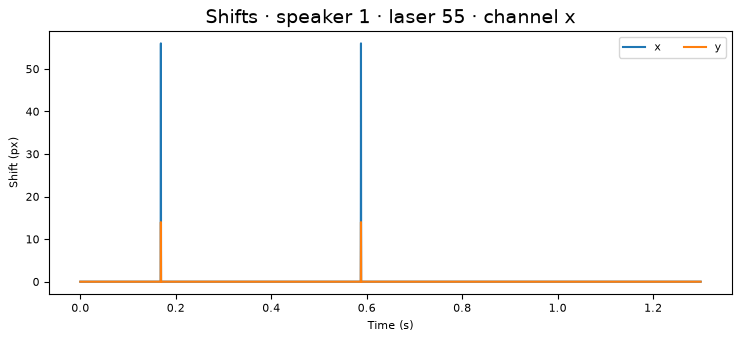

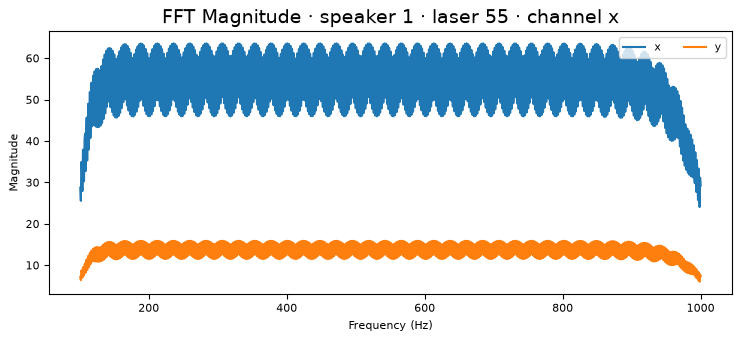

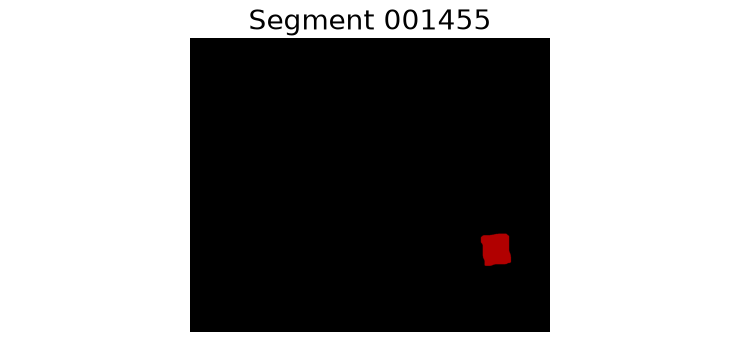

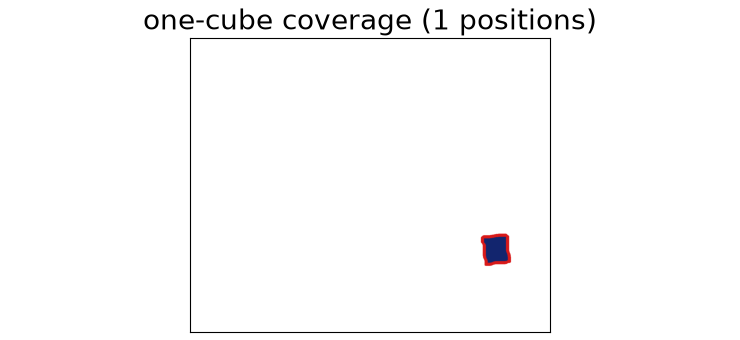

'001455'

In [43]:
position = dataclasses.replace(default_position, objects={"red-cube": 1}, prompts={"red-cube": exp.prompts["red-cube"]}, layout="one-cube")
record_position_and_plot(hw, exp, segmenter, position, default_preview, save=False)

# 9. GUI

Optional: a browser window onto the same `hw`, `exp` and `LAST`. Its buttons call the functions above.
Live video is MJPEG straight from the cameras; the browser does all drawing, zoom and overlays.

In [44]:
import uvicorn
from fastapi import FastAPI, HTTPException
from fastapi.responses import FileResponse, Response, StreamingResponse

STATIC = REPO_DIR / "record2" / "static"
app = FastAPI()


def as_json(x): return Response(json.dumps(x, default=to_json), media_type="application/json")


def not_while_recording():
    if RECORDING.locked():
        raise HTTPException(409, "recording -- wait for the position to finish")


def mjpeg(name, read):
    # the stream IS the camera reader: one frame read, encoded and sent at a time; a slow browser
    # just means older frames are never read (no queue, no lag)
    def frames():
        sent, t0, last_error = 0, time.time(), None
        while True:
            try:
                frame = read()
            except Exception as e:  # e.g. the laser camera being rebuilt for new ROIs
                if repr(e) != last_error:
                    logger.warning(f"{name} feed: {e!r}")
                    last_error = repr(e)
                time.sleep(0.2)
                continue
            if frame is None:
                time.sleep(0.003)
                continue
            jpg = cv2.imencode(".jpg", frame[..., ::-1] if frame.ndim == 3 else frame, [cv2.IMWRITE_JPEG_QUALITY, 85])[1]
            yield b"--frame\r\nContent-Type: image/jpeg\r\n\r\n" + jpg.tobytes() + b"\r\n"
            sent += 1
            if time.time() - t0 > 30:
                logger.info(f"{name} feed: {sent / (time.time() - t0):.1f} fps")
                sent, t0 = 0, time.time()
    return StreamingResponse(frames(), media_type="multipart/x-mixed-replace; boundary=frame")


NO_CACHE = {"Cache-Control": "no-cache"}  # the browser re-checks the page and its files on every load: an edited
                                          # index.html never runs with a stale cached app.js (which can crash it)


@app.get("/")
def index(): return FileResponse(STATIC / "index.html", headers=NO_CACHE)


@app.get("/static/{name}")
def static(name: str):
    if name not in ("app.js", "style.css"):
        raise HTTPException(404)
    return FileResponse(STATIC / name, headers=NO_CACHE)


@app.get("/overhead.mjpg")
def overhead_feed(): return mjpeg("overhead", lambda: hw.overhead_cam.capture())


@app.get("/laser.mjpg")
def laser_feed(): return mjpeg("laser", lambda: hw.laser_cam.preview_frame())  # hw.laser_cam: calibration replaces it


@app.get("/laser_sensor.jpg")
def laser_sensor():
    # the whole sensor, from the last wide-open frame (the ROI cells, or the GUI's calibration): the unzoomed laser
    # view draws it dimmed under the live bands -- the camera itself never reads the rows between them
    frame = globals().get("wide_open_frame")
    if frame is None:
        raise HTTPException(404)
    return Response(cv2.imencode(".jpg", frame, [cv2.IMWRITE_JPEG_QUALITY, 85])[1].tobytes(), media_type="image/jpeg")


@app.get("/catalog")
def catalog():
    return as_json(dict(boxes=exp.crop_box, prompts=exp.prompts, speaker_position=exp.speaker_position,
                        speakers=sorted(hw.audio_engine.config.speaker_device_names), layouts=sorted(exp.positions_per_layout),
                        position=dataclasses.asdict(default_position), preview=dataclasses.asdict(default_preview),
                        roi_defaults={f.name: f.default for f in dataclasses.fields(ROIConfig) if f.name in ("n_rows", "n_cols", "roi_width", "roi_height")}))


@app.get("/state")
def state(since: int = 0):
    oc, lc = hw.overhead_cam.config, hw.laser_cam.config
    roi = None if lc.roi is None else {k: getattr(lc.roi, k) for k in ("rows", "cols", "crop", "roi_width", "roi_height", "rois", "row_positions", "offset_x")}
    return as_json(dict(
        recording=RECORDING.locked(), position_id=LAST.get("position_id"), next_position_id=exp.position_ids.peek(), experiment_dir=str(exp.experiment_dir),
        panels={panel: "none" if key not in LAST else "loading" if not LAST[key].done() else "failed" if LAST[key].exception() else "ready"
                for panel, key in PANELS.items()},
        counts=dict(experiment=sum(exp.positions_per_layout.values()), layouts=dict(exp.positions_per_layout)),
        overhead=dict(exposure=oc.exposure_ms, gain=oc.gain, exposure_bounds=oc.exposure_bounds_ms, gain_bounds=oc.gain_bounds,
                      fps=hw.overhead_cam.frame_rate, fps_bounds=oc.frame_rate_bounds,
                      size=[hw.overhead_cam.width, hw.overhead_cam.height]),
        laser=dict(exposure=lc.exposure_us, gain=lc.gain, exposure_bounds=lc.exposure_bounds_us, gain_bounds=lc.gain_bounds,
                   fps=lc.fps, fps_bounds=lc.fps_bounds, fps_step=lc.buffer_part_count / hw.audio_engine.config.speaker_padding,  # a capture stays whole buffers
                   size=[hw.laser_cam.width, hw.laser_cam.height], sensor=[lc.sensor_width, lc.sensor_height], roi=roi),
        records=[r for r in list(TAIL) if r["seq"] > since]))


@app.get("/panel/{name}.png")
def panel(name: str, w: int = 740, h: int = 340, layout: str | None = None):
    # drawn at exactly the browser's box size (w x h px), so the plot fills it
    if name not in PANELS or "position_id" not in LAST and name != "coverage":
        raise HTTPException(404)
    w, h = min(max(w, 100), 4000), min(max(h, 100), 4000)
    buf = io.BytesIO()
    # timed on the timeline: segmentation + coverage on the position's row, shifts + fft on the previewed sample's
    label = LAST.get("position_id", "") + ("" if PANELS[name] == "seg" else f"-{LAST['preview_config'].speaker}")
    with Timing(label, f"plot {name}") if label else contextlib.nullcontext():
        fig = draw(name, (w / 100, h / 100), layout)
        if fig is not None:
            fig.savefig(buf, format="png", dpi=100)
    if fig is None:
        raise HTTPException(404)
    return Response(buf.getvalue(), media_type="image/png")


@app.get("/preview.wav")
def preview_wav():
    f = LAST.get("preview")
    if f is None or not f.done() or f.exception() is not None:
        raise HTTPException(404)
    buf = io.BytesIO()
    sf.write(buf, f.result()["recovered_audio"], f.result()["audio_sample_rate"], format="WAV")
    return Response(buf.getvalue(), media_type="audio/wav")


@app.post("/run")
def run(body: dict):
    not_while_recording()
    try:
        position, preview = PositionConfig(**body["position"]), PreviewConfig(**body["preview"])
    except (TypeError, ValueError) as e:
        raise HTTPException(400, str(e))
    LAST.clear()
    RECORD_POOL.submit(record_position, hw, exp, segmenter, position, preview, body.get("save", True), body.get("vibrate", True))


@app.post("/log")
def log_from_browser(body: dict): logger.info(f"browser: {body['msg']}")  # e.g. the recovered audio playing on the default output


@app.post("/stop")
def stop(): STOP.set()


@app.post("/camera")
def camera(body: dict):
    not_while_recording()
    cam = hw.overhead_cam if body["cam"] == "overhead" else hw.laser_cam
    if "exposure" in body: cam.set_exposure(float(body["exposure"]))
    if "gain" in body: cam.set_gain(float(body["gain"]))
    if "fps" in body and body["cam"] == "overhead":  # a new rate: reopen the camera at it
        hw.overhead_cam = PyueyeCamera(dataclasses.replace(cam.config, frame_rate=float(body["fps"])))
    if "fps" in body and body["cam"] == "laser":
        hw.laser_cam = MikrotronCamera(dataclasses.replace(cam.config, fps=float(body["fps"])))


@app.post("/calibrate")
def calibrate():
    not_while_recording()
    hw.laser_cam = open_calibration_camera(hw.laser_cam.config)


@app.post("/rois")
def rois(body: dict):
    not_while_recording()
    try:
        roi = ROIConfig(rows=body["rows"], cols=body["cols"], crop=body["crop"], roi_width=int(body["roi_width"]), roi_height=int(body["roi_height"]))
    except ValueError as e:
        raise HTTPException(400, str(e))
    save_rois(roi)
    global wide_open_frame
    if hw.laser_cam.config.roi is None:  # calibrating: keep the whole sensor's picture before cropping to the grid
        wide_open_frame = hw.laser_cam.capture_latest_frame()
    hw.laser_cam = MikrotronCamera(dataclasses.replace(hw.laser_cam.config, roi=roi))  # closes the current one


@app.post("/delete")
def delete(body: dict):
    try:
        return as_json(delete_position(exp, body["position_id"]))
    except RuntimeError as e:
        raise HTTPException(409, str(e))


def start_gui(port=8765):
    server = uvicorn.Server(uvicorn.Config(app, host="127.0.0.1", port=port, log_level="warning"))
    threading.Thread(target=server.run, daemon=True, name="http").start()
    return server

# 10 Launch GUI

In [45]:
if "gui" in globals():
    gui.should_exit = True  # re-running: stop the old server first
    time.sleep(1)
gui = start_gui()
p = "http://127.0.0.1:8765"
webbrowser.open(p)
p

'http://127.0.0.1:8765'